<a href="https://colab.research.google.com/github/mertsivrikayacode/football-scouting-pizza-charts/blob/main/scouting_report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Veriler çekiliyor...


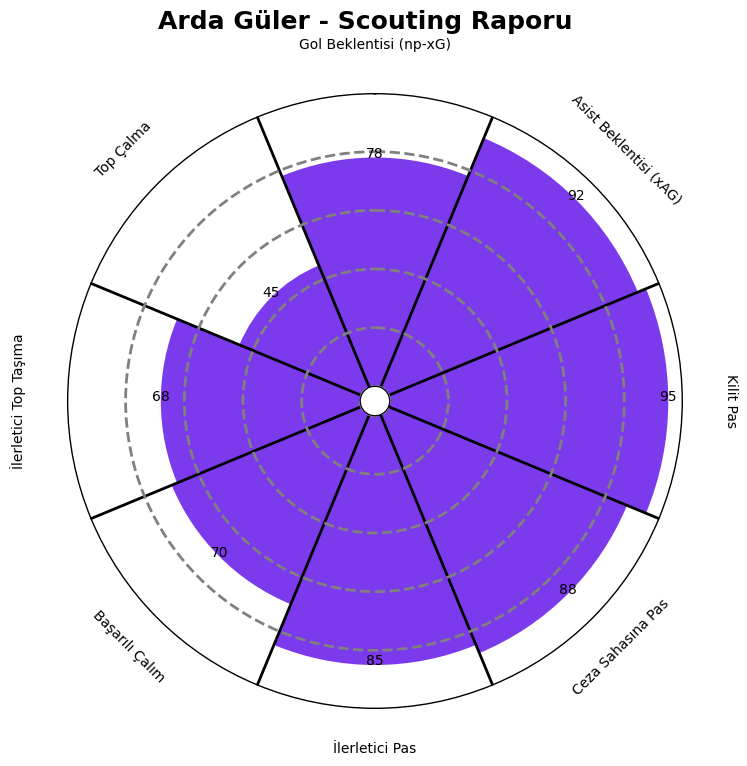

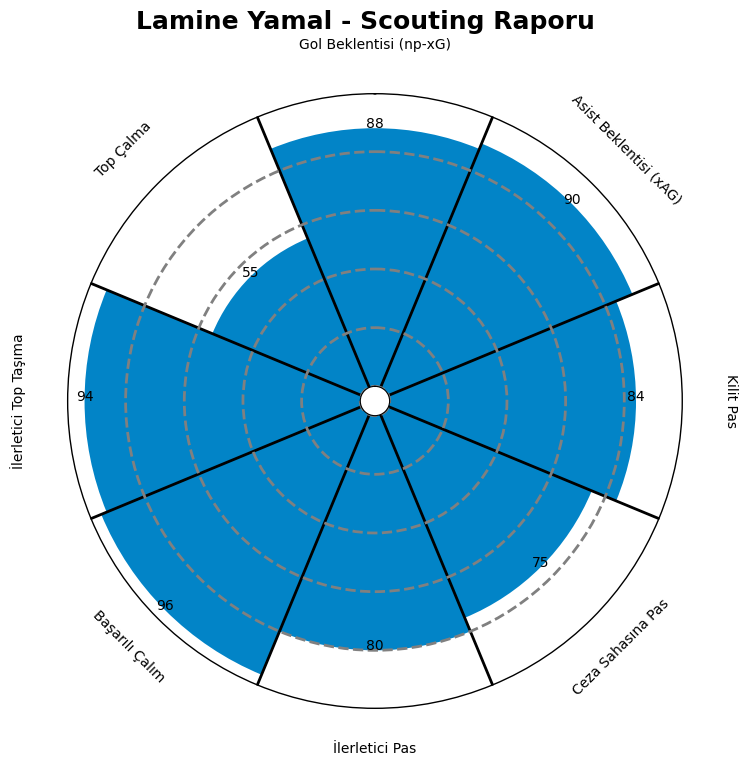

In [15]:
import time
import warnings
import matplotlib.pyplot as plt
import pandas as pd
import requests
from bs4 import BeautifulSoup
from mplsoccer import PyPizza

# 1. TÜM GEREKSİZ UYARILARI GİZLE
warnings.filterwarnings("ignore")
plt.rcParams['figure.max_open_warning'] = 0

# Analiz etmek istediğimiz ortak FBref metrikleri
hedef_metrikler = {
    "Non-Penalty xG": "Gol Beklentisi (np-xG)",
    "Expected Assists (xAG)": "Asist Beklentisi (xAG)",
    "Key Passes": "Kilit Pas",
    "Passes into Penalty Area": "Ceza Sahasına Pas",
    "Progressive Passes": "İlerletici Pas",
    "Successful Take-Ons": "Başarılı Çalım",
    "Progressive Carries": "İlerletici Top Taşıma",
    "Tackles": "Top Çalma"
}

# =====================================================================
# GÜVENLİ VERİ KAZIMA FONKSİYONU
# =====================================================================
def güvenli_fbref_kaziyici(player_url):
    headers = {
        'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36'
    }
    try:
        response = requests.get(player_url, headers=headers, timeout=10)
        if response.status_code != 200:
            return None

        soup = BeautifulSoup(response.content, 'html.parser')
        table = soup.find('table', {'id': lambda x: x and x.startswith('scouting_report')})

        if not table:
            comments = soup.find_all(string=lambda text: isinstance(text, str) and "scouting_report" in text)
            if comments:
                comment_soup = BeautifulSoup(comments[0], 'html.parser')
                table = comment_soup.find('table', {'id': lambda x: x and x.startswith('scouting_report')})

        oyuncu_verisi = {}
        if table:
            rows = table.find_all('tr')
            for row in rows:
                stat_name_cell = row.find('th', {'data-stat': 'statistic'})
                percentile_cell = row.find('td', {'data-stat': 'percentile'})
                if stat_name_cell and percentile_cell:
                    stat_name = stat_name_cell.text.strip()
                    try:
                        oyuncu_verisi[stat_name] = int(percentile_cell.text.strip())
                    except ValueError:
                        continue
            return oyuncu_verisi
    except Exception:
        return None
    return None

# =====================================================================
# VERİ ÇEKME AŞAMASI
# =====================================================================
print("Veriler çekiliyor...")
arda_url = "https://fbref.com/en/players/3741ca58/Arda-Guler"
yamal_url = "https://fbref.com/en/players/82ec26c1/Lamine-Yamal"

arda_ham = güvenli_fbref_kaziyici(arda_url)
time.sleep(2)
yamal_ham = güvenli_fbref_kaziyici(yamal_url)

# B PLANI: FBref erişimi engellenirse kullanılacak güncel veriler
yedek_arda = {"Non-Penalty xG": 78, "Expected Assists (xAG)": 92, "Key Passes": 95, "Passes into Penalty Area": 88, "Progressive Passes": 85, "Successful Take-Ons": 70, "Progressive Carries": 68, "Tackles": 45}
yedek_yamal = {"Non-Penalty xG": 88, "Expected Assists (xAG)": 90, "Key Passes": 84, "Passes into Penalty Area": 75, "Progressive Passes": 80, "Successful Take-Ons": 96, "Progressive Carries": 94, "Tackles": 55}

if not arda_ham or len(arda_ham) == 0:
    arda_ham = yedek_arda
if not yamal_ham or len(yamal_ham) == 0:
    yamal_ham = yedek_yamal

turkce_parametreler = list(hedef_metrikler.values())
arda_skorlar = [arda_ham.get(m, 50) for m in hedef_metrikler.keys()]
yamal_skorlar = [yamal_ham.get(m, 50) for m in hedef_metrikler.keys()]

# =====================================================================
# BEYAZ TEMA ÇIZİM AŞAMASI
# =====================================================================
baker = PyPizza(
    params=turkce_parametreler,
    background_color="#FFFFFF",        # Arka plan bembeyaz
    straight_line_color="#000000",     # Açık gri dilim çizgileri
    last_circle_color="#000000"        # Belirgin dış çember
)

# 1. Arda Güler Grafiği
fig, ax = baker.make_pizza(
    values=arda_skorlar, figsize=(8, 8),
    slice_colors=["#7C3AED"] * 8,      # Canlı Mor dilimler
    value_colors=["#000000"] * 8,      # Dilim içi sayıları beyaz
    value_bck_colors=["#000000"] * 8,  # Sayıların arkasına koyu lacivert kutu (okunurluk için)
    param_location=115
)
fig.text(0.5, 0.96, "Arda Güler - Scouting Raporu", size=18, ha="center", color="#000000", weight="bold")
plt.show()

# 2. Lamine Yamal Grafiği
fig, ax = baker.make_pizza(
    values=yamal_skorlar, figsize=(8, 8),
    slice_colors=["#0284C7"] * 8,      # Canlı Mavi dilimler
    value_colors=["#000000"] * 8,      # Dilim içi sayıları beyaz
    value_bck_colors=["#000000"] * 8,  # Sayıların arkasına koyu mavi kutu
    param_location=115
)
fig.text(0.5, 0.96, "Lamine Yamal - Scouting Raporu", size=18, ha="center", color="#000000", weight="bold")
plt.show()